In [37]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, model_selection

In [38]:
X,y = datasets.load_diabetes(return_X_y=True)
print(X.shape)
print(X[:2], y[:2])

(442, 10)
[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]] [151.  75.]


In [39]:
# X = X[:,4].reshape((-1,1))

In [40]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X,y, test_size=0.2)

## Linear regression

In [41]:
model = linear_model.LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
y_pred = model.predict(X_test)

In [43]:
from sklearn.metrics import mean_squared_error, r2_score

In [44]:
def eval_model(model,X_test):
    # Evaluate the model using the test data
    y_pred = model.predict(X_test)
    plt.plot(y_test,y_test,'-b')
    plt.plot(y_test,y_pred, '.r')
    mse = mean_squared_error(y_test, y_pred)
    print("MSE:", mse)
    rmse = np.sqrt(mse)
    print("RMSE:", rmse)
    r2 = r2_score(y_test, y_pred)
    print("R2:", r2)
    return y_pred

MSE: 2812.3327009603245
RMSE: 53.0314312550616
R2: 0.4323933990216484


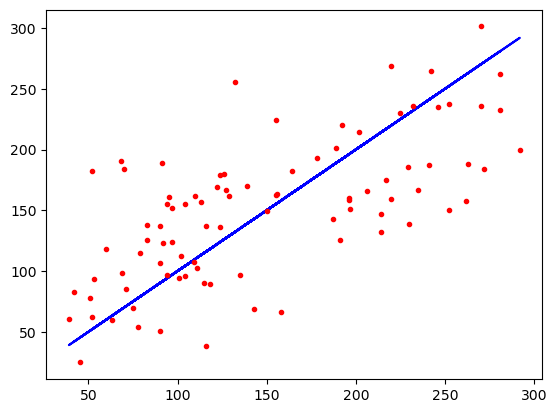

In [45]:
y_pred_lr = eval_model(model,X_test)

## Lasso

Lasso() 

MSE: 3316.0526786949595
RMSE: 57.58517759541043
R2: 0.3307287615805603


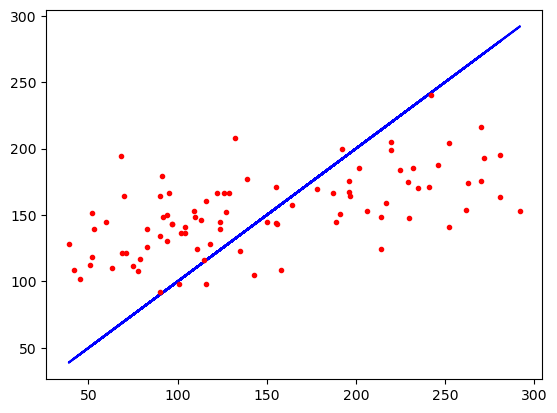

In [46]:
from sklearn.linear_model import Lasso

# Fit a lasso model on the training set
model = Lasso().fit(X_train, y_train)
print (model, "\n")
y_pred_lasso = eval_model(model,X_test)

## Decision Tree

In [47]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_text

# Train the model
model = DecisionTreeRegressor().fit(X_train, y_train)
print (model, "\n")

# Visualize the model tree
tree = export_text(model)
print(tree)

DecisionTreeRegressor() 

|--- feature_2 <= 0.01
|   |--- feature_8 <= 0.02
|   |   |--- feature_6 <= 0.02
|   |   |   |--- feature_3 <= 0.05
|   |   |   |   |--- feature_1 <= 0.00
|   |   |   |   |   |--- feature_0 <= -0.05
|   |   |   |   |   |   |--- feature_2 <= -0.05
|   |   |   |   |   |   |   |--- feature_6 <= -0.02
|   |   |   |   |   |   |   |   |--- feature_9 <= -0.04
|   |   |   |   |   |   |   |   |   |--- value: [142.00]
|   |   |   |   |   |   |   |   |--- feature_9 >  -0.04
|   |   |   |   |   |   |   |   |   |--- value: [162.00]
|   |   |   |   |   |   |   |--- feature_6 >  -0.02
|   |   |   |   |   |   |   |   |--- feature_2 <= -0.07
|   |   |   |   |   |   |   |   |   |--- value: [134.00]
|   |   |   |   |   |   |   |   |--- feature_2 >  -0.07
|   |   |   |   |   |   |   |   |   |--- feature_8 <= -0.00
|   |   |   |   |   |   |   |   |   |   |--- feature_8 <= -0.03
|   |   |   |   |   |   |   |   |   |   |   |--- value: [55.00]
|   |   |   |   |   |   |   |   |   |   

MSE: 6185.640449438202
RMSE: 78.64884264525577
R2: -0.2484334976373599


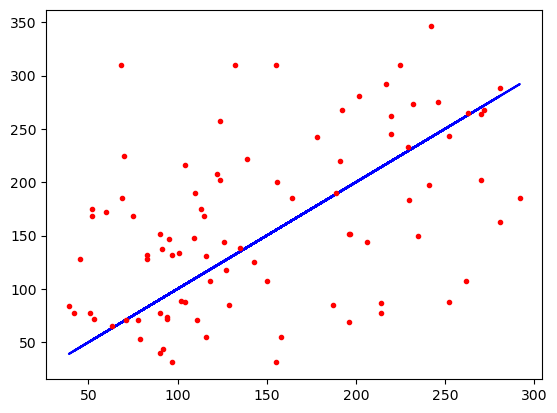

In [48]:
y_pred_dt = eval_model(model,X_test)

## Random Forest
Takes average of decision trees

RandomForestRegressor() 

MSE: 3093.7853224719097
RMSE: 55.62180617772053
R2: 0.37558846773521615


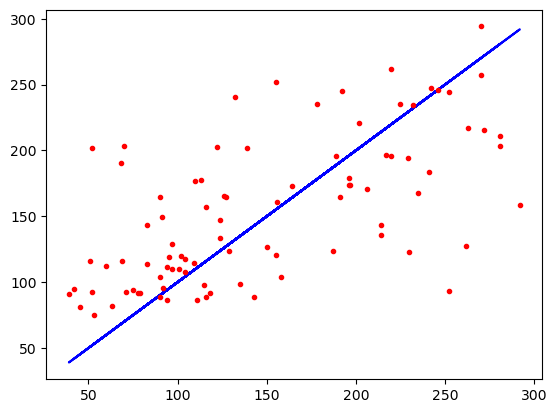

In [49]:
from sklearn.ensemble import RandomForestRegressor

# Train the model
model = RandomForestRegressor().fit(X_train, y_train)
print (model, "\n")

y_pred_rf = eval_model(model,X_test)

## Gradient Boost
Builds decision trees on results from other decision trees

GradientBoostingRegressor() 

MSE: 3153.6783331223232
RMSE: 56.15762043678777
R2: 0.36350039999485495


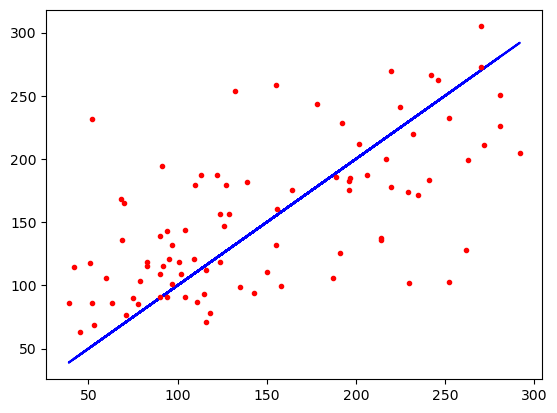

In [50]:
# Train the model
from sklearn.ensemble import GradientBoostingRegressor

# Fit a lasso model on the training set
model = GradientBoostingRegressor().fit(X_train, y_train)
print (model, "\n")
y_pred_gbr = eval_model(model,X_test)

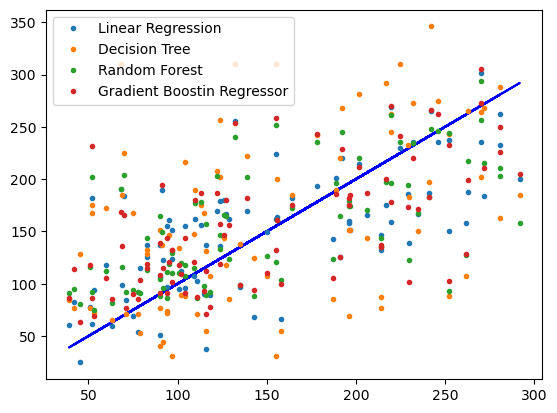

In [51]:
plt.plot(y_test,y_test,'-b')
plt.plot(y_test,y_pred_lr,'.',label='Linear Regression')
plt.plot(y_test,y_pred_dt,'.',label='Decision Tree')
plt.plot(y_test,y_pred_rf,'.',label='Random Forest')
plt.plot(y_test,y_pred_gbr,'.',label='Gradient Boostin Regressor')
plt.legend()

## Improving Gradient Boost hyperparameters
### Grid search
Adapting learning_rate and n_estimatore

Best parameter combination: {'learning_rate': 0.15, 'n_estimators': 25} 

GradientBoostingRegressor(learning_rate=0.15, n_estimators=25) 

MSE: 2857.447875169636
RMSE: 53.455101488722626
R2: 0.42328790781260706


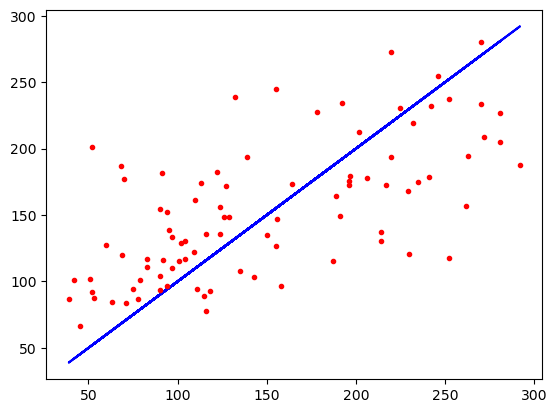

In [52]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, r2_score

# Use a Gradient Boosting algorithm
alg = GradientBoostingRegressor()

# Try these hyperparameter values
params = {
 'learning_rate': [0.1, 0.07, 0.15],
 'n_estimators' : [30, 25, 20]
 }

# Find the best hyperparameter combination to optimize the R2 metric
score = make_scorer(r2_score)
gridsearch = GridSearchCV(alg, params, scoring=score, cv=3, return_train_score=True)
gridsearch.fit(X_train, y_train)
print("Best parameter combination:", gridsearch.best_params_, "\n")

# Get the best model
model=gridsearch.best_estimator_
print(model, "\n")

y_pred_gbr2 = eval_model(model,X_test)